In [39]:
from lsfb_dataset import LSFBIsolConfig, LSFBIsolLandmarks
from mediapipe.python.solutions.drawing_utils import plot_landmarks
from numba.np.polynomial.polynomial_functions import numpy_polyadd
from numpy.ma.core import maximum
from sympy.stats.sampling.sample_numpy import numpy

dataset = LSFBIsolLandmarks(LSFBIsolConfig(
    root="C:/Users/abassoma/Documents/Dataset/Lsfb_dataset/isol",
    split="train",
    n_labels=500,
    sequence_max_length=50
))

features, target = dataset[0]

100%|██████████| 51066/51066 [00:21<00:00, 2430.32it/s]


In [41]:
keys_distribution = {}
for signs in dataset:
    elem, _ = signs
    el = elem['pose'].shape[0]
    keys_distribution[el] = keys_distribution.get(el, 0) + 1
print(keys_distribution)

{13: 2953, 18: 2359, 12: 2884, 27: 928, 14: 2922, 9: 1529, 16: 2732, 17: 2538, 11: 2623, 10: 2188, 19: 2223, 21: 1790, 20: 1922, 25: 1148, 28: 873, 39: 258, 7: 505, 15: 2949, 23: 1527, 30: 717, 8: 955, 37: 284, 32: 551, 24: 1344, 50: 1817, 22: 1630, 33: 526, 38: 257, 42: 224, 44: 176, 29: 745, 26: 1075, 31: 599, 40: 276, 47: 138, 41: 210, 36: 365, 34: 438, 45: 150, 35: 412, 43: 189, 6: 185, 48: 117, 46: 175, 0: 490, 49: 113, 5: 43, 4: 14}


In [42]:
m,_ = dataset[58]
import numpy as np
print(m['left_hand'].shape)
l = m['left_hand']
r = m['right_hand']
p = m['pose']
print(l.shape, r.shape, p.shape)
sign = np.concatenate((l,r,p), axis=1)
print(sign.shape)
print(sign)

(8, 21, 2)
(8, 21, 2) (8, 21, 2) (8, 33, 2)
(8, 75, 2)
[[[0.4873 0.7183]
  [0.4573 0.6836]
  [0.4233 0.6733]
  ...
  [0.3154 1.631 ]
  [0.379  1.71  ]
  [0.3071 1.687 ]]

 [[0.4868 0.718 ]
  [0.4563 0.6836]
  [0.422  0.674 ]
  ...
  [0.3127 1.63  ]
  [0.3772 1.708 ]
  [0.3062 1.686 ]]

 [[0.4863 0.7163]
  [0.4558 0.683 ]
  [0.421  0.6733]
  ...
  [0.3105 1.63  ]
  [0.3752 1.708 ]
  [0.3047 1.685 ]]

 ...

 [[0.4817 0.7104]
  [0.4517 0.6772]
  [0.4163 0.6675]
  ...
  [0.3093 1.623 ]
  [0.3718 1.701 ]
  [0.301  1.683 ]]

 [[0.4797 0.7065]
  [0.4502 0.673 ]
  [0.4143 0.6636]
  ...
  [0.309  1.618 ]
  [0.371  1.699 ]
  [0.2993 1.681 ]]

 [[0.4766 0.7007]
  [0.4475 0.6665]
  [0.4116 0.658 ]
  ...
  [0.309  1.614 ]
  [0.3757 1.701 ]
  [0.2986 1.679 ]]]


In [43]:
import torch
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=dataset, batch_size=32, shuffle=True)
x = next(iter(train_loader))

RuntimeError: stack expects each tensor to be equal size, but got [13, 33, 2] at entry 0 and [18, 33, 2] at entry 1

In [44]:
feature = [np.concatenate((elem['left_hand'], elem['right_hand']), axis=0) for elem, _ in dataset]
feature = [items.reshape(items.shape[:1] +(-1,)) for items in feature]
max_frame = max(frame.shape[0] for frame in feature)
print(max_frame)

ValueError: cannot reshape array of size 0 into shape (0,newaxis)

<BarContainer object of 48 artists>

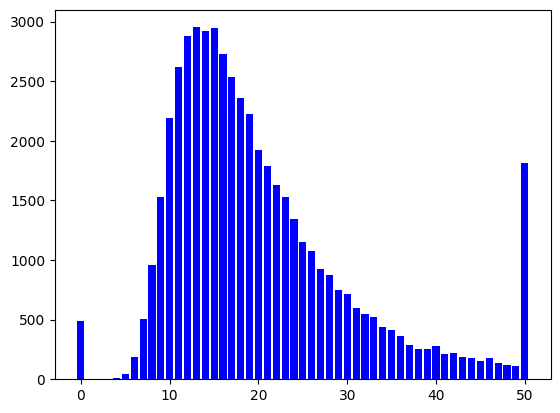

In [45]:
import matplotlib.pyplot as plt
plt.bar(keys_distribution.keys(), keys_distribution.values(), color='b')

16


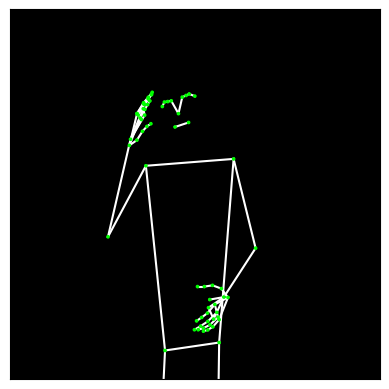

[[-0.0007324 -0.002197 ]
 [-0.0002441 -0.002075 ]
 [ 0.0002441 -0.002197 ]
 [ 0.0002441 -0.00232  ]
 [ 0.        -0.002075 ]
 [-0.0002441 -0.003052 ]
 [ 0.0007324 -0.00464  ]
 [ 0.001221  -0.0008545]
 [ 0.002441  -0.00415  ]
 [ 0.0002441 -0.001465 ]
 [ 0.        -0.002441 ]
 [ 0.001953   0.001465 ]
 [ 0.000977  -0.00537  ]
 [ 0.000977   0.000977 ]
 [-0.001953  -0.02637  ]
 [ 0.         0.000977 ]
 [ 0.001465  -0.06494  ]
 [ 0.0004883  0.001465 ]
 [ 0.01172   -0.0679   ]
 [ 0.000977   0.       ]
 [ 0.01099   -0.0637   ]
 [ 0.000977   0.       ]
 [ 0.006836  -0.0598   ]
 [ 0.        -0.001465 ]
 [ 0.001465  -0.000977 ]
 [ 0.001953  -0.003906 ]
 [ 0.005127  -0.001953 ]
 [ 0.003418  -0.004883 ]
 [ 0.005127  -0.003906 ]
 [ 0.003418  -0.003906 ]
 [ 0.004883  -0.00586  ]
 [ 0.004883  -0.006836 ]
 [ 0.004395  -0.00293  ]]


In [72]:
from sign_language_tools.visualization.plot.landmarks import *
from sign_language_tools.pose.mediapipe.edges import *
sign, _ = dataset[49]
print(sign['left_hand'].shape[0])
left_hand = sign['left_hand'][5]
right_hand = sign['right_hand'][5]
right_hand_next = sign['pose'][7]
pose = sign['pose'][5]
plot_landmarks(left_hand, HAND_EDGES)
plot_landmarks(right_hand, HAND_EDGES)
plot_landmarks(pose,POSE_EDGES)
plt.show()
diff = pose - right_hand_next
print(diff)

In [24]:
import torch
x = torch.randn(4, 10)
even_poss = x[:, ::2]
print(even_poss.index())

AttributeError: 'Tensor' object has no attribute 'index'

In [43]:
x = torch.randn(4, 20)
import math
even_poss =  torch.arange(0,20,2)
odd_poss =  torch.arange(1,20,2)
div_term = 10000 ** (even_poss/ 512)
even_p = torch.sin(even_poss / div_term)
print(even_p)

tensor([ 0.0000,  0.9364, -0.5486, -0.7815,  0.6008,  0.8778, -0.2429, -0.9937,
        -0.5380,  0.4392])


In [47]:
x = torch.randn(20)
x.expand(4,20)

tensor([[-1.3218, -0.5651,  1.0596,  1.1139, -0.4558, -1.5486,  0.8054,  0.8231,
         -2.0709, -0.0200,  0.7626, -0.4170,  0.7623,  1.6054, -1.0754, -0.8413,
         -0.4914,  0.2493, -0.6195,  0.3953],
        [-1.3218, -0.5651,  1.0596,  1.1139, -0.4558, -1.5486,  0.8054,  0.8231,
         -2.0709, -0.0200,  0.7626, -0.4170,  0.7623,  1.6054, -1.0754, -0.8413,
         -0.4914,  0.2493, -0.6195,  0.3953],
        [-1.3218, -0.5651,  1.0596,  1.1139, -0.4558, -1.5486,  0.8054,  0.8231,
         -2.0709, -0.0200,  0.7626, -0.4170,  0.7623,  1.6054, -1.0754, -0.8413,
         -0.4914,  0.2493, -0.6195,  0.3953],
        [-1.3218, -0.5651,  1.0596,  1.1139, -0.4558, -1.5486,  0.8054,  0.8231,
         -2.0709, -0.0200,  0.7626, -0.4170,  0.7623,  1.6054, -1.0754, -0.8413,
         -0.4914,  0.2493, -0.6195,  0.3953]])

In [5]:
import torch
import einops
from einops import rearrange
x  = torch.randn(512,10,10)
#x = rearrange(x,'batch frame dim -> batch (frame dim)')
print(x.shape)
import torch
import torch.nn as nn
linear = nn.Linear(10,20)
y = linear(x)
print(y.shape)

torch.Size([512, 10, 10])
torch.Size([512, 10, 20])


In [12]:
x = torch.randn(1,1,512)
x = x.expand(100,-1,-1)
print(x.shape)

torch.Size([100, 1, 512])


In [15]:
encoder_layer = nn.TransformerEncoderLayer(
    d_model=512, nhead=8, batch_first=True
)
src = torch.rand(32, 10, 512)
out = encoder_layer(src)
print(out.shape)

torch.Size([32, 10, 512])


In [22]:
mask = [[True]*20]*20
print(mask)

[[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True], [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True], [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True], [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True], [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True], [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True], [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True], [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True], [True, True, True, True

In [32]:
import torch
x = torch.zeros(4,1)
print(x)
y = torch.ones(4,3)
print(x.shape)
z = torch.cat([y,x], dim=1)
print(z.shape)

tensor([[0.],
        [0.],
        [0.],
        [0.]])
torch.Size([4, 1])
torch.Size([4, 4])


In [38]:
import numpy as np
x =np.zeros(0)
print(x)

[]
